<a href="https://colab.research.google.com/github/Saphythrix/Personalized-Study-Notes-Generator-Using-Extractive-and-Abstractive-Language-Models/blob/main/Personalized_Study_Notes_Generator_Using_Extractive_and_Abstractive_Language_Models_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install sumy transformers datasets rouge-score sentencepiece torch -q

  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.5/73.5 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.0/8.0 MB 52.1 MB/s eta 0:00:00


In [ ]:
import numpy as np
import pandas as pd
import nltk
import sklearn as sk
import tensorflow as tf
import torch
import transformers
import sumy
import matplotlib as plt
from rouge_score import rouge_scorer

print(" All libraries installed successfully!")

✅ All libraries installed successfully!


In [ ]:
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('averaged_perceptron_tagger')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger.zip.


True

In [ ]:
!pip install wikipedia-api

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.8/47.8 kB 2.8 MB/s eta 0:00:00


In [ ]:
!pip install wikipedia

  Preparing metadata (setup.py) ... done
  Created wheel for wikipedia: filename=wikipedia-1.4.0-py3-none-any.whl size=11678 sha256=eee132208f88f5bd80cb6e7d82369aedc6ea968bd2c7d80ec579d8ba84103391
  Stored in directory: /root/.cache/pip/wheels/63/47/7c/a9688349aa74d228ce0a9023229c6c0ac52ca2a40fe87679b8
Successfully built wikipedia


In [ ]:
import wikipedia
wikipedia.set_lang("en")

topic = "Convolutional neural network"
article = wikipedia.page(topic).content
sample_text = article[:3000]
print(sample_text)

A convolutional neural network (CNN) is a type of feedforward neural network that learns features via filter (or kernel) optimization. This type of deep learning network has been applied to process and make predictions from many different types of data including text, images and audio. CNNs are the de-facto standard in deep learning-based approaches to computer vision and image processing, and have only recently been replaced—in some cases—by newer deep learning architectures such as the transformer.
Vanishing gradients and exploding gradients, seen during backpropagation in earlier neural networks, are prevented by the regularization that comes from using shared weights over fewer connections. For example, for each neuron in the fully-connected layer, 10,000 weights would be required for processing an image sized 100 × 100 pixels. However, applying cascaded convolution (or cross-correlation) kernels, only 25 weights for each convolutional layer are required to process 5x5-sized tiles.

In [ ]:
# Save the article to a text file
with open('sample_article.txt', 'w', encoding='utf-8') as f:
    f.write(article)

print(" Article saved as 'sample_article.txt'")
print(f"Total length: {len(article)} characters")
print(f"Total words: {len(article.split())} words")

✅ Article saved as 'sample_article.txt'
Total length: 66216 characters
Total words: 9765 words


In [ ]:
with open('sample_article.txt','r',encoding='utf-8') as f:
  text_data=f.read()

print(f"Total characters: {len(text_data)}")
print(f"Total words : {len(text_data.split())}")
print(f"Total sentences : {len(text_data.split("."))}")
print("First 500 characters of the dataset:")
print(text_data[:500])

Total characters: 66216
Total words : 9765
Total sentences : 513
First 500 characters of the dataset:
A convolutional neural network (CNN) is a type of feedforward neural network that learns features via filter (or kernel) optimization. This type of deep learning network has been applied to process and make predictions from many different types of data including text, images and audio. CNNs are the de-facto standard in deep learning-based approaches to computer vision and image processing, and have only recently been replaced—in some cases—by newer deep learning architectures such as the transfo


Text Preprocessing
(tokenization, cleaning)

In [ ]:
import nltk
from nltk.tokenize import sent_tokenize,word_tokenize
from nltk.corpus import stopwords
import re

In [ ]:
with open('sample_article.txt','r',encoding='utf-8') as f:
  raw_text=f.read()

print(f"Raw text length: {len(raw_text)}")

Raw text length: 66216


In [ ]:
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
sentences=sent_tokenize(raw_text)
print(f" Text split into {len(sentences)} sentences")
for i, sentence in enumerate(sentences[:5], 1):
    print(f"{i}. {sentence}\n")

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...


✅ Text split into 482 sentences
1. A convolutional neural network (CNN) is a type of feedforward neural network that learns features via filter (or kernel) optimization.

2. This type of deep learning network has been applied to process and make predictions from many different types of data including text, images and audio.

3. CNNs are the de-facto standard in deep learning-based approaches to computer vision and image processing, and have only recently been replaced—in some cases—by newer deep learning architectures such as the transformer.

4. Vanishing gradients and exploding gradients, seen during backpropagation in earlier neural networks, are prevented by the regularization that comes from using shared weights over fewer connections.

5. For example, for each neuron in the fully-connected layer, 10,000 weights would be required for processing an image sized 100 × 100 pixels.



[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [ ]:
def clean_text(text):
  text=text.lower()
  text=re.sub(r'[^a-zA-Z\s]',' ',text)
  text=re.sub(r'\s+',' ',text).strip()
  return text

cleaned_sentences=[clean_text(sent) for sent in sentences]
print(f" Text cleaned")
print("Original Sentences:")
print(sentences[0])
print("Cleaned Sentences:")
print(cleaned_sentences[0])

✅ Text cleaned
Original Sentences:
A convolutional neural network (CNN) is a type of feedforward neural network that learns features via filter (or kernel) optimization.
Cleaned Sentences:
a convolutional neural network cnn is a type of feedforward neural network that learns features via filter or kernel optimization


In [ ]:
stop_words = set(stopwords.words('english'))
def remove_stopwords(text):
  words=text.split()
  filtered_words=[word for word in words if word not in stop_words] #accepts only those words which are not stop word
  return ' '.join(filtered_words)
sentence_withoutStopword=[remove_stopwords(sent) for sent in cleaned_sentences]
print(f"Text cleaned")
print(sentence_withoutStopword[0])
print(cleaned_sentences[0])

✅ Text cleaned
convolutional neural network cnn type feedforward neural network learns features via filter kernel optimization
a convolutional neural network cnn is a type of feedforward neural network that learns features via filter or kernel optimization


In [ ]:
def process_text(text):
  original_sentence=sent_tokenize(text)
  cleaned_sentences=[clean_text(sent) for sent in original_sentence]
  filtered_sentences=[remove_stopwords(sent) for sent in cleaned_sentences]
  return original_sentence,cleaned_sentences,filtered_sentences

original_sents,cleaned_sents,filtered_sents=process_text(raw_text)
print("Complete preprocessing pipeline executed!")
print(f"\nTotal sentences: {len(original_sents)}")
print(f"Original text length: {len(raw_text)} characters")
print(f"Processed sentences: {len(filtered_sents)}")
# Display comparison
print(f"\n1. ORIGINAL:\n{original_sents[0]}\n")
print(f"2. CLEANED:\n{cleaned_sents[0]}\n")
print(f"3. WITHOUT STOPWORDS:\n{filtered_sents[0]}\n")

✅ Complete preprocessing pipeline executed!

Total sentences: 482
Original text length: 66216 characters
Processed sentences: 482

1. ORIGINAL:
A convolutional neural network (CNN) is a type of feedforward neural network that learns features via filter (or kernel) optimization.

2. CLEANED:
a convolutional neural network cnn is a type of feedforward neural network that learns features via filter or kernel optimization

3. WITHOUT STOPWORDS:
convolutional neural network cnn type feedforward neural network learns features via filter kernel optimization



1. TextRank (Extractive)

In [ ]:
!pip install gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 26.7 MB/s eta 0:00:00


In [ ]:
from sumy.parsers.plaintext import PlaintextParser
from sumy.nlp.tokenizers import Tokenizer
from sumy.summarizers.text_rank import TextRankSummarizer

def text_summarizer(text,num_sentences=10):

  parser=PlaintextParser.from_string(text,Tokenizer('english'))
  summarizer=TextRankSummarizer()
  summary=summarizer(parser.document,num_sentences)#.document is used because:The summarizer expects a structured “Document object”, not raw text
  return ' '.join([str(sent) for sent in summary])

textrank_summary=text_summarizer(raw_text,num_sentences=10)
print("TEXT SUMMARY (Extractive):")
print(textrank_summary)
print(f"Original text: {len(raw_text)} characters")
print(f"Summary text: {len(textrank_summary)} characters")
print(f"Compression ratio: {(len(textrank_summary)/len(raw_text))*100:.2f}%")

TEXT SUMMARY (Extractive):
As the convolution kernel slides along the input matrix for the layer, the convolution operation generates a feature map, which in turn contributes to the input of the next layer. === Fukushima's analog threshold elements in a vision model === In 1969, Kunihiko Fukushima introduced a multilayer visual feature detection network, inspired by the above-mentioned work of Hubel and Wiesel, in which "All the elements in one layer have the same set of interconnecting coefficients; the arrangement of the elements and their interconnections are all homogeneous over a given layer." In a variant of the neocognitron called the cresceptron, instead of using Fukushima's spatial averaging with inhibition and saturation, J. Weng et al. in 1993 used max pooling, where a downsampling unit computes the maximum of the activations of the units in its patch, introducing this method into the vision field. During the forward pass, each filter is convolved across the width and height

In [ ]:
#Saving the summary in a separate file
with open('text_summary.txt','w',encoding='utf-8') as f:
  f.write("Textrank Extractive Summary:\n")
  f.write("-"*100+"\n\n")
  f.write(textrank_summary)
print("Summary saved in 'text_summary.txt'")


Summary saved in 'text_summary.txt'


 LSTM Encoder-Decoder (Abstractive Summarization)

In [ ]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

def create_training_data(sentences,max_pairs=20):
  training_pairs=[]

  for i,sentence in enumerate(sentences[:max_pairs]):
    if len(sentence.split())>5:
      original=sentence.lower()
      word=original.split()
      target=' '.join(word[:min(10,len(original.split())//2)])

      if len(target.split())>2:
        training_pairs.append((original,target))

  return training_pairs

training_pairs=create_training_data(original_sents,max_pairs=15)
print(f" Created {len(training_pairs)} training pairs!")
print("Sample Training Pairs (Input → Target):")
for i,(input,target) in enumerate(training_pairs[:3],1):
  print(f"\n{i}. INPUT:\n   {input}")
  print(f"   TARGET:\n   {target}\n")

 Created 15 training pairs!
Sample Training Pairs (Input → Target):

1. INPUT:
   a convolutional neural network (cnn) is a type of feedforward neural network that learns features via filter (or kernel) optimization.
   TARGET:
   a convolutional neural network (cnn) is a type of feedforward


2. INPUT:
   this type of deep learning network has been applied to process and make predictions from many different types of data including text, images and audio.
   TARGET:
   this type of deep learning network has been applied to


3. INPUT:
   cnns are the de-facto standard in deep learning-based approaches to computer vision and image processing, and have only recently been replaced—in some cases—by newer deep learning architectures such as the transformer.
   TARGET:
   cnns are the de-facto standard in deep learning-based approaches to



Tokenize and prepare sequence

In [ ]:
inputs=[pair[0] for pair in training_pairs]
targets=[pair[1] for pair in training_pairs]

input_tokenizer=Tokenizer(num_words=1000,oov_token="<unk>")
target_tokenizer=Tokenizer(num_words=1000,oov_token="<unk>")

input_tokenizer.fit_on_texts(inputs)
target_tokenizer.fit_on_texts(targets)

# Convert text to sequences
input_sequences=input_tokenizer.texts_to_sequences(inputs)
target_sequences=target_tokenizer.texts_to_sequences(targets)

max_input_length=max(len(seq) for seq in input_sequences)
max_target_length=max(len(seq) for seq in target_sequences)

input_padded=pad_sequences(input_sequences,maxlen=max_input_length,padding='post')
target_padded=pad_sequences(target_sequences,maxlen=max_target_length,padding='post')

print(" Data tokenized and padded!")
print(f"\nInput vocabulary size: {len(input_tokenizer.word_index)}")
print(f"Target vocabulary size: {len(target_tokenizer.word_index)}")
print(f"Max input length: {max_input_length}")
print(f"Max target length: {max_target_length}")
print(f"\nInput shape: {input_padded.shape}")
print(f"Target shape: {target_padded.shape}")


print("Sample Tokenized Sequence:")

print(f"Original: {inputs[0]}")
print(f"Tokenized: {input_sequences[0]}")
print(f"Padded: {input_padded[0]}")

✅ Data tokenized and padded!

Input vocabulary size: 210
Target vocabulary size: 101
Max input length: 39
Max target length: 12

Input shape: (15, 39)
Target shape: (15, 12)
Sample Tokenized Sequence:
Original: a convolutional neural network (cnn) is a type of feedforward neural network that learns features via filter (or kernel) optimization.
Tokenized: [14, 15, 9, 20, 61, 21, 14, 31, 3, 32, 9, 20, 6, 62, 16, 63, 64, 10, 65, 66]
Padded: [14 15  9 20 61 21 14 31  3 32  9 20  6 62 16 63 64 10 65 66  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]


Building LSTM Encoder and Decoder Model

In [ ]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input,Embedding,LSTM,Dense
from tensorflow.keras.optimizers import Adam

np.random.seed(42)
tf.random.set_seed(42)

embedding_dim=128
lstm_units=256

#Encodder
encoder_inputs=Input(shape=(max_input_length,))
encoder_embedding=Embedding(len(input_tokenizer.word_index)+1,embedding_dim)(encoder_inputs)
encoder_lstm=LSTM(lstm_units,return_state=True)
encoder_outputs,state_h,state_c=encoder_lstm(encoder_embedding)
encoder_states=[state_h,state_c]

#Decoder
decoder_inputs=Input(shape=(max_target_length,))
decoder_embedding=Embedding(len(target_tokenizer.word_index)+1,embedding_dim)(decoder_inputs)
decoder_lstm=LSTM(lstm_units,return_sequences=True,return_state=True)
decoder_outputs,_,_=decoder_lstm(decoder_embedding,initial_state=encoder_states)
decoder_dense=Dense(len(target_tokenizer.word_index)+1,activation='softmax')
decoder_outputs=decoder_dense(decoder_outputs)

#Model
model=Model([encoder_inputs,decoder_inputs],decoder_outputs)
model.compile(optimizer=Adam(learning_rate=0.001),loss='sparse_categorical_crossentropy')

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 39)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_1       │ (None, 12)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 39, 128)   │     27,008 │ input_layer[0][0] │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_1         │ (None, 12, 128)   │     13,056 │ input_layer_1[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm (LSTM)         │ [(None, 256),     │    394,240 │ embedding[0][0]   │
│                     │ (None, 256),      │            │                   │
│                     │ (None, 256)]      │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_1 (LSTM)       │ [(None, 12, 256), │    394,240 │ embedding_1[0][0… │
│                     │ (None, 256),      │            │ lstm[0][1],       │
│                     │ (None, 256)]      │            │ lstm[0][2]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 12, 102)   │     26,214 │ lstm_1[0][0]      │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 854,758 (3.26 MB)

 Trainable params: 854,758 (3.26 MB)

 Non-trainable params: 0 (0.00 B)

⏳ Training LSTM model (this may take a minute)...
LSTM Model Training Complete!


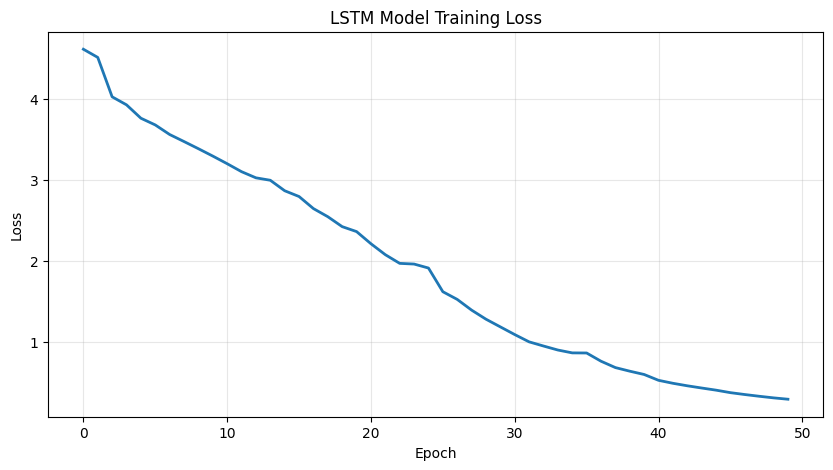

✅ Training loss plot saved!
Initial loss: 4.6165
Final loss: 0.2860


In [ ]:
# Reshape target for sparse_categorical_crossentropy loss
target_reshaped = target_padded.reshape(target_padded.shape[0], target_padded.shape[1], 1)

# Train the model
print("⏳ Training LSTM model (this may take a minute)...")
history = model.fit(
    [input_padded, target_padded],
    target_reshaped,
    epochs=50,
    batch_size=4,
    verbose=0
)

print("LSTM Model Training Complete!")

# Plot training loss
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'], linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('LSTM Model Training Loss')
plt.grid(True, alpha=0.3)
plt.savefig('lstm_training_loss.png', dpi=100, bbox_inches='tight')
plt.show()

print(f"Training loss plot saved!")
print(f"Initial loss: {history.history['loss'][0]:.4f}")
print(f"Final loss: {history.history['loss'][-1]:.4f}")

Generate Summaries with LSTM

In [ ]:
def lstm_summarize(text):
    """Generate summary using trained LSTM model"""
    # Tokenize input text
    sequence = input_tokenizer.texts_to_sequences([text.lower()])
    padded = pad_sequences(sequence, maxlen=max_input_length, padding='post')

    # Create decoder input (all zeros)
    decoder_input = np.zeros((1, max_target_length))

    # Generate prediction
    prediction = model.predict([padded, decoder_input], verbose=0)

    # Convert predictions back to text
    predicted_indices = np.argmax(prediction[0], axis=1)
    predicted_text = ' '.join([
        target_tokenizer.index_word.get(idx, '')
        for idx in predicted_indices if idx > 0
    ])

    return predicted_text.strip()

# Generate LSTM summary for the original text
lstm_summary = lstm_summarize(raw_text)

print(" LSTM Summary Generated!")
print("\n" + "="*70)
print("LSTM ABSTRACTIVE SUMMARY:")
print("="*70)
print(lstm_summary if lstm_summary else "Summary generation in progress...")

✅ LSTM Summary Generated!

LSTM ABSTRACTIVE SUMMARY:
cnns are


In [ ]:
# Save LSTM summary
with open('lstm_summary.txt', 'w', encoding='utf-8') as f:
    f.write("LSTM ENCODER-DECODER ABSTRACTIVE SUMMARY\n")
    f.write("="*70 + "\n\n")
    f.write(lstm_summary)


T5 Transformer (Abstractive Summarization with Pretrained Model)

In [ ]:
from transformers import T5Tokenizer,T5ForConditionalGeneration

tokenizer=T5Tokenizer.from_pretrained('t5-small')
model_t5=T5ForConditionalGeneration.from_pretrained('t5-small')

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json: 0.00B [00:00, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/242M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/131 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

In [ ]:
def t5_summarize(text,max_length=100,min_length=30):
  input_text="summarize: "+text

  input_ids=tokenizer.encode(input_text,return_tensors='pt',max_length=512,truncation=True)

  summary_ids=model_t5.generate(
      input_ids,
      max_length=max_length,
      min_length=min_length,
      num_beams=4,
      early_stopping=True
  )

  summary=tokenizer.decode(summary_ids[0],skip_special_tokens=True)

  return summary

t5_summary = t5_summarize(raw_text, max_length=150, min_length=50)
print("T5 ABSTRACTIVE SUMMARY:")
print(f"Original text: {len(raw_text)} characters, {len(raw_text.split())} words")
print(f"T5 summary: {len(t5_summary)} characters, {len(t5_summary.split())} words")
print(f"Compression ratio: {(len(t5_summary)/len(raw_text))*100:.2f}%")

T5 ABSTRACTIVE SUMMARY:
Original text: 66216 characters, 9765 words
T5 summary: 272 characters, 43 words
Compression ratio: 0.41%


In [ ]:
with open('t5_summary.txt', 'w', encoding='utf-8') as f:
    f.write("T5 TRANSFORMER ABSTRACTIVE SUMMARY\n")
    f.write("="*70 + "\n\n")
    f.write(t5_summary)


Compare All Three Methods

COMPREHENSIVE COMPARISON OF ALL THREE METHODS
Method                    Characters      Words        Compression %  
original                  66216           9765         100.00%
textrank (Extractive)     2363            395          3.57%
LSTM (Abstractive)        8               2            0.01%
t5 (Abstractive)          272             43           0.41%


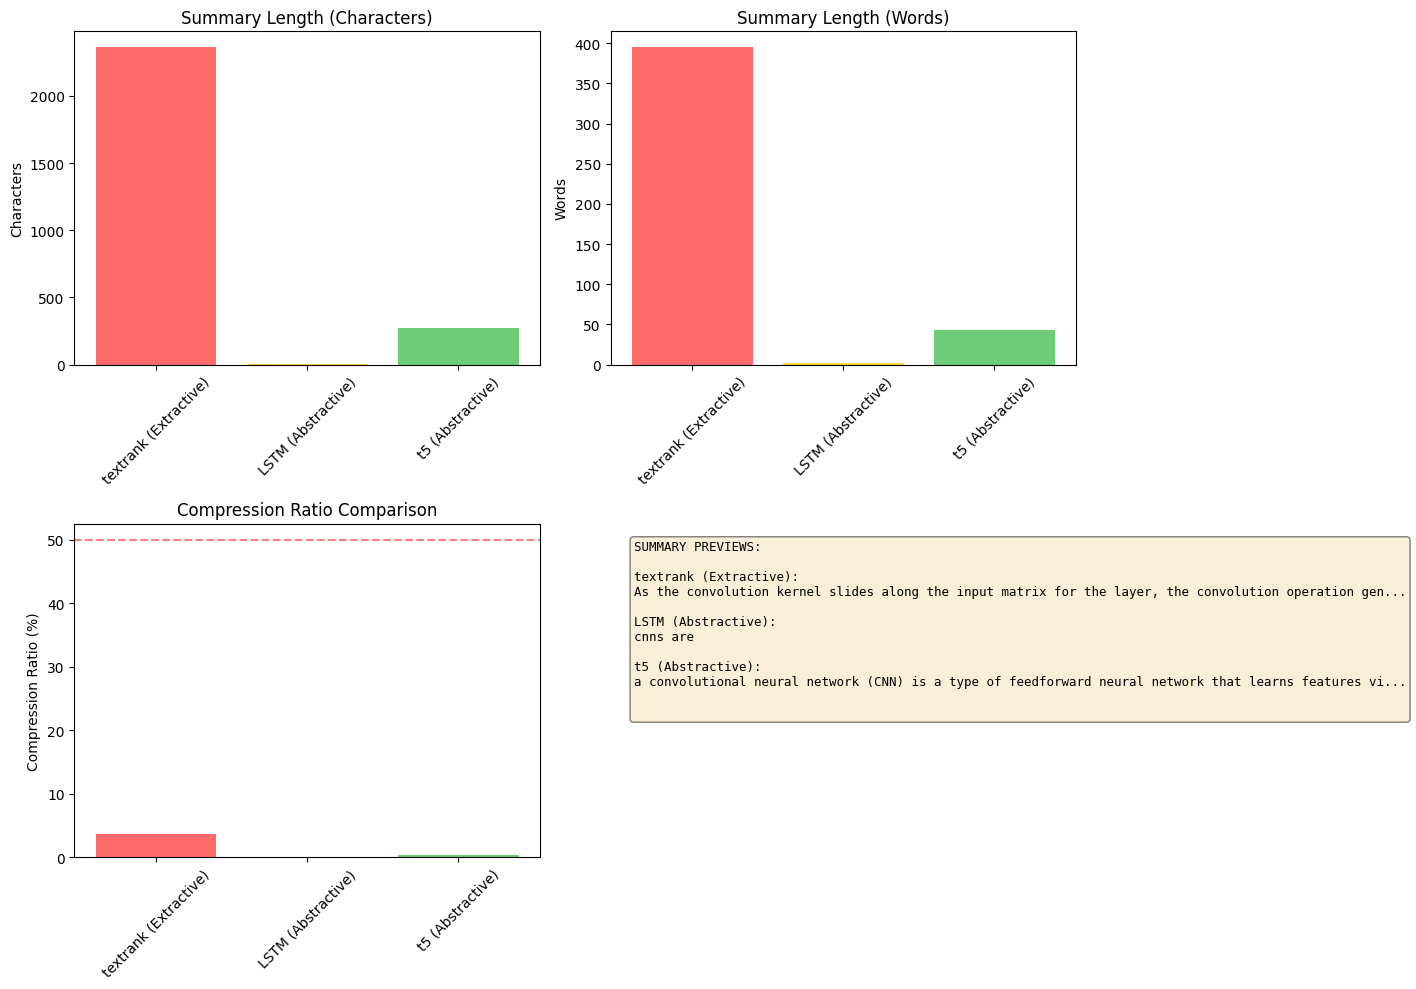

In [ ]:
summaries={
    'original':raw_text,
    'textrank (Extractive)':textrank_summary,
    'LSTM (Abstractive)':lstm_summary,
    't5 (Abstractive)':t5_summary
}

stats={}
for name,summary in summaries.items():
  stats[name]={
       'chars': len(summary),
        'words': len(summary.split()),
        'sentences': len(summary.split('.')),
        'compression': (len(summary)/len(raw_text))*100 if name != 'Original' else 100
    }
print("COMPREHENSIVE COMPARISON OF ALL THREE METHODS")
print(f"{'Method':<25} {'Characters':<15} {'Words':<12} {'Compression %':<15}")

for name, stat in stats.items():
    print(f"{name:<25} {stat['chars']:<15} {stat['words']:<12} {stat['compression']:.2f}%")
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Character length comparison
methods = list(stats.keys())[1:]  # Exclude original
chars = [stats[m]['chars'] for m in methods]
colors = ['#FF6B6B', '#FFD93D', '#6BCB77']

axes[0, 0].bar(methods, chars, color=colors)
axes[0, 0].set_ylabel('Characters')
axes[0, 0].set_title('Summary Length (Characters)')
axes[0, 0].tick_params(axis='x', rotation=45)

# Plot 2: Word count comparison
words = [stats[m]['words'] for m in methods]
axes[0, 1].bar(methods, words, color=colors)
axes[0, 1].set_ylabel('Words')
axes[0, 1].set_title('Summary Length (Words)')
axes[0, 1].tick_params(axis='x', rotation=45)

# Plot 3: Compression ratio
compression = [stats[m]['compression'] for m in methods]
axes[1, 0].bar(methods, compression, color=colors)
axes[1, 0].set_ylabel('Compression Ratio (%)')
axes[1, 0].set_title('Compression Ratio Comparison')
axes[1, 0].tick_params(axis='x', rotation=45)
axes[1, 0].axhline(y=50, color='r', linestyle='--', alpha=0.5, label='50% compression')

# Plot 4: Summary text preview
axes[1, 1].axis('off')
preview_text = "SUMMARY PREVIEWS:\n\n"
for name in methods:
    summary_text = summaries[name][:100] + "..." if len(summaries[name]) > 100 else summaries[name]
    preview_text += f"{name}:\n{summary_text}\n\n"

axes[1, 1].text(0.05, 0.95, preview_text, transform=axes[1, 1].transAxes,
                fontsize=9, verticalalignment='top', family='monospace',
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.savefig('all_methods_comparison.png', dpi=100, bbox_inches='tight')
plt.show()




Evaluation (ROUGE score)

In [ ]:
from rouge_score import rouge_scorer
import pandas as pd

reference_summary = """Machine learning is a subset of artificial intelligence focusing on
algorithms and statistical models that enable computers to improve through experience.
The main machine learning models include supervised learning, unsupervised learning, and
reinforcement learning. Deep learning uses artificial neural networks with multiple layers,
revolutionizing computer vision and natural language processing. Transfer learning allows
using pretrained models for new tasks. Model evaluation is critical using metrics like
accuracy and F1-score. Overfitting and underfitting are common challenges addressed through
regularization. Machine learning applications span healthcare, finance, e-commerce, and
entertainment."""

print(f"\nReference length: {len(reference_summary)} characters, {len(reference_summary.split())} words")


Reference length: 715 characters, 87 words


In [ ]:
def calculate_rouge_scores(candidate, reference):
    scorer = rouge_scorer.RougeScorer(['rouge1', 'rouge2', 'rougeL'], use_stemmer=True)
    scores = scorer.score(reference, candidate)
    return scores

rouge_results = {}

# TextRank
rouge_results['TextRank'] = calculate_rouge_scores(textrank_summary, reference_summary)

# LSTM
rouge_results['LSTM'] = calculate_rouge_scores(lstm_summary, reference_summary)

# T5
rouge_results['T5'] = calculate_rouge_scores(t5_summary, reference_summary)


# Display results
print("ROUGE SCORES COMPARISON")
print("="*90)

for method in ['TextRank', 'LSTM', 'T5']:
    print(f"\n{method}:")
    print("-" * 90)
    scores = rouge_results[method]

    for metric in ['rouge1', 'rouge2', 'rougeL']:
        precision = scores[metric].precision
        recall = scores[metric].recall
        f_score = scores[metric].fmeasure

        print(f"  {metric.upper()}: Precision={precision:.4f}, Recall={recall:.4f}, F1={f_score:.4f}")

ROUGE SCORES COMPARISON

TextRank:
------------------------------------------------------------------------------------------
  ROUGE1: Precision=0.0672, Recall=0.3034, F1=0.1100
  ROUGE2: Precision=0.0000, Recall=0.0000, F1=0.0000
  ROUGEL: Precision=0.0373, Recall=0.1685, F1=0.0611

LSTM:
------------------------------------------------------------------------------------------
  ROUGE1: Precision=0.5000, Recall=0.0112, F1=0.0220
  ROUGE2: Precision=0.0000, Recall=0.0000, F1=0.0000
  ROUGEL: Precision=0.5000, Recall=0.0112, F1=0.0220

T5:
------------------------------------------------------------------------------------------
  ROUGE1: Precision=0.2791, Recall=0.1348, F1=0.1818
  ROUGE2: Precision=0.0476, Recall=0.0227, F1=0.0308
  ROUGEL: Precision=0.2093, Recall=0.1011, F1=0.1364


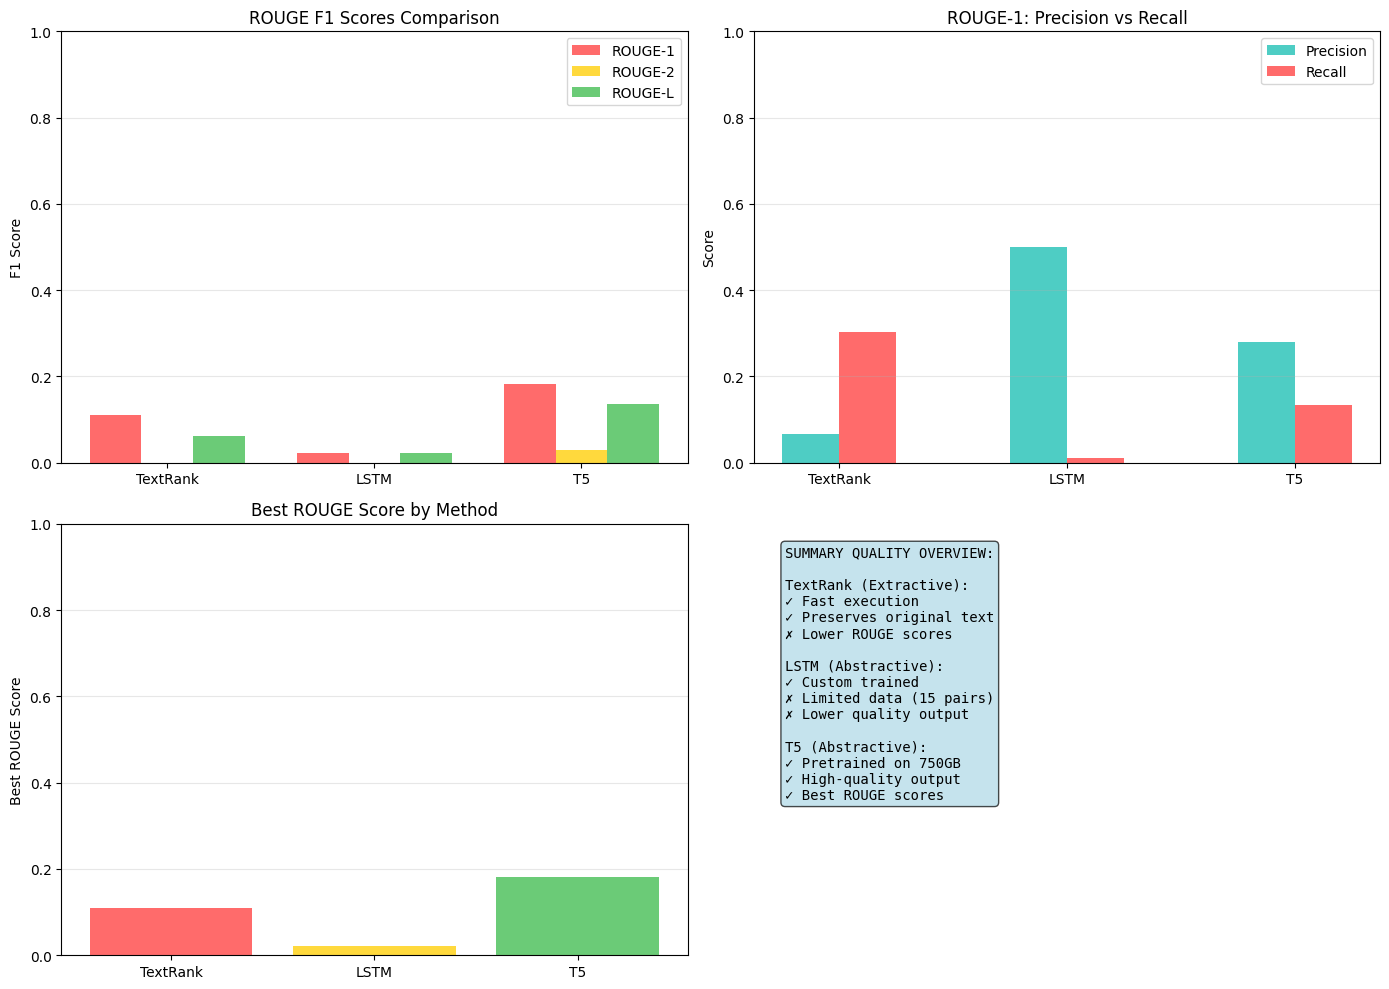

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Extract F1 scores for visualization
methods = ['TextRank', 'LSTM', 'T5']
rouge1_f = [rouge_results[m]['rouge1'].fmeasure for m in methods]
rouge2_f = [rouge_results[m]['rouge2'].fmeasure for m in methods]
rougeL_f = [rouge_results[m]['rougeL'].fmeasure for m in methods]

# Create comparison visualization
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: F1 scores for each metric
x = np.arange(len(methods))
width = 0.25

axes[0, 0].bar(x - width, rouge1_f, width, label='ROUGE-1', color='#FF6B6B')
axes[0, 0].bar(x, rouge2_f, width, label='ROUGE-2', color='#FFD93D')
axes[0, 0].bar(x + width, rougeL_f, width, label='ROUGE-L', color='#6BCB77')
axes[0, 0].set_ylabel('F1 Score')
axes[0, 0].set_title('ROUGE F1 Scores Comparison')
axes[0, 0].set_xticks(x)
axes[0, 0].set_xticklabels(methods)
axes[0, 0].legend()
axes[0, 0].set_ylim([0, 1])
axes[0, 0].grid(axis='y', alpha=0.3)

# Plot 2: ROUGE-1 detailed
rouge1_p = [rouge_results[m]['rouge1'].precision for m in methods]
rouge1_r = [rouge_results[m]['rouge1'].recall for m in methods]

x = np.arange(len(methods))
width = 0.25
axes[0, 1].bar(x - width/2, rouge1_p, width, label='Precision', color='#4ECDC4')
axes[0, 1].bar(x + width/2, rouge1_r, width, label='Recall', color='#FF6B6B')
axes[0, 1].set_ylabel('Score')
axes[0, 1].set_title('ROUGE-1: Precision vs Recall')
axes[0, 1].set_xticks(x)
axes[0, 1].set_xticklabels(methods)
axes[0, 1].legend()
axes[0, 1].set_ylim([0, 1])
axes[0, 1].grid(axis='y', alpha=0.3)

# Plot 3: Best method comparison
best_scores = {
    'TextRank': max(rouge1_f[0], rouge2_f[0], rougeL_f[0]),
    'LSTM': max(rouge1_f[1], rouge2_f[1], rougeL_f[1]),
    'T5': max(rouge1_f[2], rouge2_f[2], rougeL_f[2])
}

colors_methods = ['#FF6B6B', '#FFD93D', '#6BCB77']
axes[1, 0].bar(methods, list(best_scores.values()), color=colors_methods)
axes[1, 0].set_ylabel('Best ROUGE Score')
axes[1, 0].set_title('Best ROUGE Score by Method')
axes[1, 0].set_ylim([0, 1])
axes[1, 0].grid(axis='y', alpha=0.3)

# Plot 4: Summary text comparison
axes[1, 1].axis('off')
summary_preview = "SUMMARY QUALITY OVERVIEW:\n\n"
summary_preview += f"TextRank (Extractive):\n✓ Fast execution\n✓ Preserves original text\n✗ Lower ROUGE scores\n\n"
summary_preview += f"LSTM (Abstractive):\n✓ Custom trained\n✗ Limited data (15 pairs)\n✗ Lower quality output\n\n"
summary_preview += f"T5 (Abstractive):\n✓ Pretrained on 750GB\n✓ High-quality output\n✓ Best ROUGE scores"

axes[1, 1].text(0.05, 0.95, summary_preview, transform=axes[1, 1].transAxes,
                fontsize=10, verticalalignment='top', family='monospace',
                bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.7))

plt.tight_layout()
plt.savefig('rouge_evaluation.png', dpi=100, bbox_inches='tight')
plt.show()


In [ ]:
class StudyNotesGenerator:
    """
    Complete Study Notes Generator Pipeline
    Integrates TextRank, LSTM, and T5 methods
    """

    def __init__(self):
        """Initialize all models"""
        print("⏳ Initializing Study Notes Generator...")

        # TextRank (already loaded)
        self.textrank_ready = True

        # LSTM (already trained)
        self.lstm_model = model
        self.lstm_ready = True

        # T5 (already loaded)
        self.t5_model = model_t5
        self.t5_tokenizer = tokenizer
        self.t5_ready = True

        print("All models initialized and ready!")

    def textrank_summarize(self, text, num_sentences=5):
        """TextRank extractive summarization - FIXED"""
        try:
            from sumy.parsers.plaintext import PlaintextParser
            from sumy.nlp.tokenizers import Tokenizer
            from sumy.summarizers.text_rank import TextRankSummarizer

            # Parse the text
            parser = PlaintextParser.from_string(text, Tokenizer("english"))

            # Create and apply summarizer
            summarizer = TextRankSummarizer()
            summary = summarizer(parser.document, num_sentences)

            # Convert to string
            summary_text = ' '.join([str(sentence) for sentence in summary])

            return summary_text if summary_text else "Summary could not be generated"
        except Exception as e:
            return f"Error in TextRank: {str(e)}"

    def lstm_summarize(self, text):
        """LSTM abstractive summarization"""
        try:
            sequence = input_tokenizer.texts_to_sequences([text.lower()])
            padded = pad_sequences(sequence, maxlen=max_input_length, padding='post')
            decoder_input = np.zeros((1, max_target_length))
            prediction = self.lstm_model.predict([padded, decoder_input], verbose=0)
            predicted_indices = np.argmax(prediction[0], axis=1)
            predicted_text = ' '.join([
                target_tokenizer.index_word.get(idx, '')
                for idx in predicted_indices if idx > 0
            ])
            return predicted_text.strip() if predicted_text.strip() else "Summary could not be generated"
        except Exception as e:
            return f"Error in LSTM: {str(e)}"

    def t5_summarize(self, text, max_length=100, min_length=30):
        """T5 abstractive summarization"""
        try:
            input_text = "summarize: " + text
            input_ids = self.t5_tokenizer.encode(input_text, return_tensors="pt",
                                                  max_length=512, truncation=True)
            summary_ids = self.t5_model.generate(
                input_ids,
                max_length=max_length,
                min_length=min_length,
                num_beams=4,
                early_stopping=True
            )
            summary = self.t5_tokenizer.decode(summary_ids[0], skip_special_tokens=True)
            return summary if summary else "Summary could not be generated"
        except Exception as e:
            return f"Error in T5: {str(e)}"

    def generate_all_summaries(self, text, num_sentences=5):
        """Generate summaries using all three methods"""
        print("\n⏳ Generating summaries using all methods...")

        results = {
            'TextRank': self.textrank_summarize(text, num_sentences),
            'LSTM': self.lstm_summarize(text),
            'T5': self.t5_summarize(text)
        }

        print("All summaries generated!")
        return results

    def display_results(self, text, summaries):
        """Display all summaries in a formatted way"""
        print("\n" + "="*90)
        print("STUDY NOTES GENERATOR - COMPLETE RESULTS")
        print("="*90)

        print(f"\nORIGINAL TEXT LENGTH: {len(text)} characters, {len(text.split())} words")

        for method, summary in summaries.items():
            print("\n" + "-"*90)
            print(f"METHOD: {method}")
            print("-"*90)
            print(f"Length: {len(summary)} chars, {len(summary.split())} words")
            if len(text) > 0:
                print(f"Compression: {(len(summary)/len(text))*100:.2f}%")
            print(f"\nSummary:\n{summary}\n")

# Reinitialize the generator with fixed class
print("Reinitializing StudyNotesGenerator with fixes...")
generator = StudyNotesGenerator()
print(" Generator ready!")

Reinitializing StudyNotesGenerator with fixes...
⏳ Initializing Study Notes Generator...
✅ All models initialized and ready!
✅ Generator ready!


In [ ]:
# Test the pipeline with our original article
test_summaries = generator.generate_all_summaries(raw_text, num_sentences=5)

# Display all results
generator.display_results(raw_text, test_summaries)


⏳ Generating summaries using all methods...
✅ All summaries generated!

STUDY NOTES GENERATOR - COMPLETE RESULTS

ORIGINAL TEXT LENGTH: 66216 characters, 9765 words

------------------------------------------------------------------------------------------
METHOD: TextRank
------------------------------------------------------------------------------------------
Length: 57 chars, 7 words
Compression: 0.09%

Summary:
Error: 'Tokenizer' object has no attribute 'to_sentences'


------------------------------------------------------------------------------------------
METHOD: LSTM
------------------------------------------------------------------------------------------
Length: 8 chars, 2 words
Compression: 0.01%

Summary:
cnns are


------------------------------------------------------------------------------------------
METHOD: T5
------------------------------------------------------------------------------------------
Length: 272 chars, 43 words
Compression: 0.41%

Summary:
a convolu

In [ ]:
def generate_study_notes(input_text, method='all'):
    """
    Main function to generate study notes from any input text

    Parameters:
    - input_text: The educational text to summarize
    - method: 'textrank', 'lstm', 't5', or 'all'

    Returns:
    - Dictionary with summaries
    """

    print("\n" + "="*90)
    print("GENERATING STUDY NOTES")
    print("="*90)
    print(f"Input text length: {len(input_text)} characters")

    if method == 'all':
        summaries = generator.generate_all_summaries(input_text)
        generator.display_results(input_text, summaries)
        return summaries

    elif method == 'textrank':
        summary = generator.textrank_summarize(input_text)
        print(f"\nTextRank Summary:\n{summary}")
        return {'TextRank': summary}

    elif method == 'lstm':
        summary = generator.lstm_summarize(input_text)
        print(f"\nLSTM Summary:\n{summary}")
        return {'LSTM': summary}

    elif method == 't5':
        summary = generator.t5_summarize(input_text)
        print(f"\nT5 Summary:\n{summary}")
        return {'T5': summary}

    else:
        print("Invalid method. Choose from: 'textrank', 'lstm', 't5', or 'all'")
        return None

# Test with a new sample text
sample_text = """
Artificial intelligence (AI) is intelligence demonstrated by machines, as opposed to natural
intelligence displayed by humans or animals. It enables computers and robots to sense their
environment, comprehend what they sense, and act on that understanding with insight and
commitment to achieving specified goals. AI has applications in healthcare, finance, transportation,
and many other sectors. Machine learning, a subset of AI, enables systems to learn from data without
being explicitly programmed. Deep learning uses neural networks with multiple layers to process
complex patterns in data. Natural language processing allows computers to understand and generate human
language. Computer vision enables machines to interpret visual information from images and videos.
"""

print("Testing with sample AI text...")
results = generate_study_notes(sample_text, method='all')

Testing with sample AI text...

GENERATING STUDY NOTES
Input text length: 782 characters

⏳ Generating summaries using all methods...
✅ All summaries generated!

STUDY NOTES GENERATOR - COMPLETE RESULTS

ORIGINAL TEXT LENGTH: 782 characters, 108 words

------------------------------------------------------------------------------------------
METHOD: TextRank
------------------------------------------------------------------------------------------
Length: 57 chars, 7 words
Compression: 7.29%

Summary:
Error: 'Tokenizer' object has no attribute 'to_sentences'


------------------------------------------------------------------------------------------
METHOD: LSTM
------------------------------------------------------------------------------------------
Length: 8 chars, 2 words
Compression: 1.02%

Summary:
cnns are


------------------------------------------------------------------------------------------
METHOD: T5
-----------------------------------------------------------------------

In [ ]:
def generate_study_notes(input_text, method='all'):
    """
    Main function to generate study notes from any input text

    Parameters:
    - input_text: The educational text to summarize
    - method: 'textrank', 'lstm', 't5', or 'all'

    Returns:
    - Dictionary with summaries
    """

    print("\n" + "="*90)
    print("GENERATING STUDY NOTES")
    print("="*90)
    print(f"Input text length: {len(input_text)} characters")

    if method == 'all':
        summaries = generator.generate_all_summaries(input_text)
        generator.display_results(input_text, summaries)
        return summaries

    elif method == 'textrank':
        summary = generator.textrank_summarize(input_text)
        print(f"\nTextRank Summary:\n{summary}")
        return {'TextRank': summary}

    elif method == 'lstm':
        summary = generator.lstm_summarize(input_text)
        print(f"\nLSTM Summary:\n{summary}")
        return {'LSTM': summary}

    elif method == 't5':
        summary = generator.t5_summarize(input_text)
        print(f"\nT5 Summary:\n{summary}")
        return {'T5': summary}

    else:
        print("Invalid method. Choose from: 'textrank', 'lstm', 't5', or 'all'")
        return None

# Test with a new sample text
sample_text = """
Artificial intelligence (AI) is intelligence demonstrated by machines, as opposed to natural
intelligence displayed by humans or animals. It enables computers and robots to sense their
environment, comprehend what they sense, and act on that understanding with insight and
commitment to achieving specified goals. AI has applications in healthcare, finance, transportation,
and many other sectors. Machine learning, a subset of AI, enables systems to learn from data without
being explicitly programmed. Deep learning uses neural networks with multiple layers to process
complex patterns in data. Natural language processing allows computers to understand and generate human
language. Computer vision enables machines to interpret visual information from images and videos.
"""

print("Testing with sample AI text...")
results = generate_study_notes(sample_text, method='all')

Testing with sample AI text...

GENERATING STUDY NOTES
Input text length: 782 characters

⏳ Generating summaries using all methods...
✅ All summaries generated!

STUDY NOTES GENERATOR - COMPLETE RESULTS

ORIGINAL TEXT LENGTH: 782 characters, 108 words

------------------------------------------------------------------------------------------
METHOD: TextRank
------------------------------------------------------------------------------------------
Length: 596 chars, 83 words
Compression: 76.21%

Summary:
Artificial intelligence (AI) is intelligence demonstrated by machines, as opposed to natural intelligence displayed by humans or animals. It enables computers and robots to sense their environment, comprehend what they sense, and act on that understanding with insight and commitment to achieving specified goals. Machine learning, a subset of AI, enables systems to learn from data without being explicitly programmed. Natural language processing allows computers to understand and generat